## Creating RC class and training RC

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np


class ReservoirComputer: #class makes it easy to train and test multiple models without reinitializing global variables.
    
    def __init__(self, Nx, Nu, Ny,
                 alpha=0.9, spectral_radius=0.9, density=0.05,
                 ridge=1e-6, seed=None):                     #self refers to the specific instance of the class we're working with
                                                             #init automatically runs when you create a new instance of a class. so i will create rc1 = RC(Nx =, Nu =,...) and these will automatically be assigned to self.Nx, self.Nu,... 
        rng = np.random.default_rng(seed)                    #used to generate the internal random weights (Win, W, etc.) reproducibly.
        self.Nx, self.Nu, self.Ny = Nx, Nu, Ny               #Nx = number of neurons in reservoir, Nu = number of inputs, Ny = number of outputs
        self.alpha, self.ridge = alpha, ridge                #alpha = leak rate, ridge = lambda in ridge regression calculation
        self.Win = rng.uniform(-1, 1, size=(Nx, 1 + Nu))    #taking values from unif(-1,1) to scale it, if had taken unif(-10,10) say, then values would all be at +-1 when apply tanh
        W = rng.uniform(-1, 1, size=(Nx, Nx))               #going to make W sparse and then scale to desired spectral radius             
        W *= (rng.random((Nx, Nx)) < density)               #rng.random creates matrix of random values between 0 and 1, shape (Nx,Nx) same as W. then saying < density makes it a boolean matrix, so all values are either true or false, depending on if they are respectively < density or not. Multiplying this by W, when multiplyiny by true its same as 1, false is 0
        eigmax = max(1e-12, np.max(np.abs(np.linalg.eigvals(W))))  #safeguards against math crashing if the eigvalues are all really close to 0, can happen due to random initialisation
        self.W = (spectral_radius / eigmax) * W              #largest eigenvalue of W will now be equal to the spectral radius specified by user
        self.Wout = None  

    def step(self, x, u):  #update step for x - given previous x and previous u, step function gives next x
        x_tilde = np.tanh(self.Win @ np.concatenate(([1.0], u)) + self.W @ x) #multiply Win by bias and input (total input signal that each neuron receives from outside world+bias), add it to the current matrix multiplied by x (what each neuron receives from other neurons)
        return (1 - self.alpha) * x + self.alpha * x_tilde
                                       
    def run_reservoir(self, U, x0=None): #applying the step function to all the input, collecting the feature vectors. U is a time series of input vectors shape (T, Nu)
        T = len(U)              #no of timesteps T = the length of U, the input
        X = np.zeros((T, self.Nx))  #stores all reservoir states across time. If have 100 timesteps, 500 neurons, then shape = (100,500)
        x = np.zeros(self.Nx) if x0 is None else x0 #current reservoir state at each step. so its the state of each neuron, so if have 500 neuros, x will have length 500. if we are not given an initial state, then just start with all 0s
        for t in range(T):
            x = self.step(x, U[t])  #U[t]: input at time step t, allows for vectors
            X[t] = x                
        return X
                                    #washing out the first 10 steps so reservoir forgets initial state. Note Ytarget is the output we want
    def train(self, U, Ytarget, washout=10): #training Wout by ridge regression adds a lambda||Wout||^2 term, penalises large weights and prevents overfitting
        X = self.run_reservoir(U)
        bias = np.ones((len(U), 1))  #vertical vector of 1s - T (=lenU) rows and 1 column
        Z = np.hstack([bias, U, X])  #stacking the features into an array, shape (T, 1+Nu+Nx)
        Z, Ytarget = Z[washout:], Ytarget[washout:] #getting rid of first washout steps, so reservoir can forget its initial 0 state
        I = np.eye(Z.shape[1])       # identity matrix of size Z.shape[1]- meaning the number of columns of Z = 1+Nu+Nx
        self.Wout = np.linalg.solve(Z.T @ Z + self.ridge * I, Z.T @ Ytarget).T  #ridge formula
        return self

    def predict(self, U_test, K): #predict k steps after warmup sequence
        x0 = np.zeros(self.Nx) 
        X = self.run_reservoir(U_test, x0 = x0)
        bias = np.ones((len(U_test),1))
        Z = np.hstack([bias, U_test, X])
        Yhat = Z@self.Wout.T
        x_last = X[-1]
        y_last = Yhat[-1] #taking the final reservoir state and input from test sequence, to be used to start prediction loop
        Y_future = np.zeros((K,self.Ny))
        for k in range(K):
            x_next = self.step(x_last, y_last)
            z_next = np.hstack([1.0, y_last, x_next])
            y_next = z_next@ self.Wout.T
            Y_future[k] = y_next
            x_last = x_next
            y_last = y_next
        return Y_future 

    def autonomous_step(self, x_last, y_last): #the mapping from the previous reservoir state and output to the next reservoir state and output
        x_next = self.step(x_last, y_last)
        z = np.hstack([1.0, y_last, x_next])
        y_next = z@self.Wout.T
        return x_next, y_next

    def autonomous_run(self, x0, y0, n_steps): #given an initial x0 and y0, will run the reservoir for n_steps autonomously, returning X and Y
        X = np.zeros((n_steps, self.Nx))
        Y = np.zeros((n_steps, self.Ny))
        for i in range(n_steps):
            x,y = self.autonomous_step(x0, y0)
            X[i] = x
            Y[i] = y
            x0 = x
            y0 = y
        return X, Y

#train reservoir on the following training sequence - logistic map
r = 3.8 #control parameter, = 3.8 for chaotic behaviour
T = 300 #number of steps
s = np.zeros(T + 1) 
s[0] = 0.5  # initial condition
for n in range(1,T+1): #generate logistic map sequence
    s[n] = r * s[n-1] * (1 - s[n-1])
U = s[:-1][:,None] #rc expects 2D matrix with shape (T,Nu), meaning a column vector, with each row an input. But x is just a horizontal vector of values, so [:, None] turns it in to shape we need
Ytarget = s[1:][:,None] #similarly, changing from a horizontal vector to column vector to get shape (T,Ny) instead of (T,)
#training reservoir
rc = ReservoirComputer(Nx=400, Nu=1, Ny=1, alpha=0.8,
                           spectral_radius=0.9, density=0.05,
                           ridge=1e-6, seed=1)
rc.train(U=U, Ytarget=Ytarget)
        

##Plot of average prediction horizons for different warm-up lengths

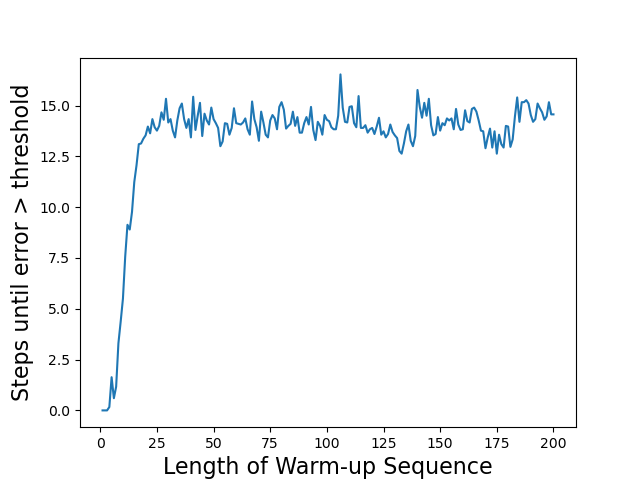

In [2]:
#graph of average prediction horizon vs warm-up length
error_threshold = 0.1
r = 3.8
K = 50
T_max = 200                                   #largest test length
n_runs = 30                                   #number of times we repeat for different initial values
test_lengths = range(1, T_max+1)              #test lengths can be anything between 1 and 200
first_index_all = np.zeros((n_runs, T_max+1)) #first index where error exceeds threshold

for run in range(n_runs):                      #so will be repeating the below process 30 times, each with a different initial value
    s_full = np.zeros(T_max + K + 1)           #logistic map able to store up to test+future values
    rng = np.random.default_rng(123+run)
    s_full[0] = rng.uniform(0,1)               #initial value a random number between 0 and 1
    for i in range(1, len(s_full)):            #making logistic map
        s_full[i] = r * s_full[i-1] * (1 - s_full[i-1])
    for T_test in test_lengths:
        s_test = s_full[:T_test+1]             #test sequence is up until T_test
        U_test = s_test[:-1][:, None]          #input is test sequence except the last value
        y_future = rc.predict(U_test, K).squeeze()
        s_future_true = s_full[T_test+1:T_test+1+K]  #true future is just the next K points of s_full after T_Test
    
        error = np.abs(y_future - s_future_true) #get error at each step
        idx = np.argmax(error > error_threshold) #argmax returns the first true value for error>threshold
        if (error > error_threshold).any():      #but if all values are false, and so the error never exceeds the threshold, it will return 0, which is incorrect, hence the if statement
            first_index_all[run,T_test] = idx    #any checks if any step has a true value. if it does, then the first index is indeed the idx
        else:                                    #but if no step has a true value, then we say the first index is the final time
            first_index_all[T_test] = K          #stayed accurate entire time

mean_first_index = np.mean(first_index_all[:,1:], axis = 0) #getting the mean first index from all the runs for each test length

plt.figure()
plt.plot(test_lengths, mean_first_index)
plt.xlabel("Length of Warm-up Sequence", fontsize=16)
plt.ylabel("Steps until error > threshold", fontsize=16)
plt.savefig("predhor_vs_wrmlgth.png", dpi=600, bbox_inches="tight")
plt.show()



##Plot showing the order of the sequential Monte Carlo search

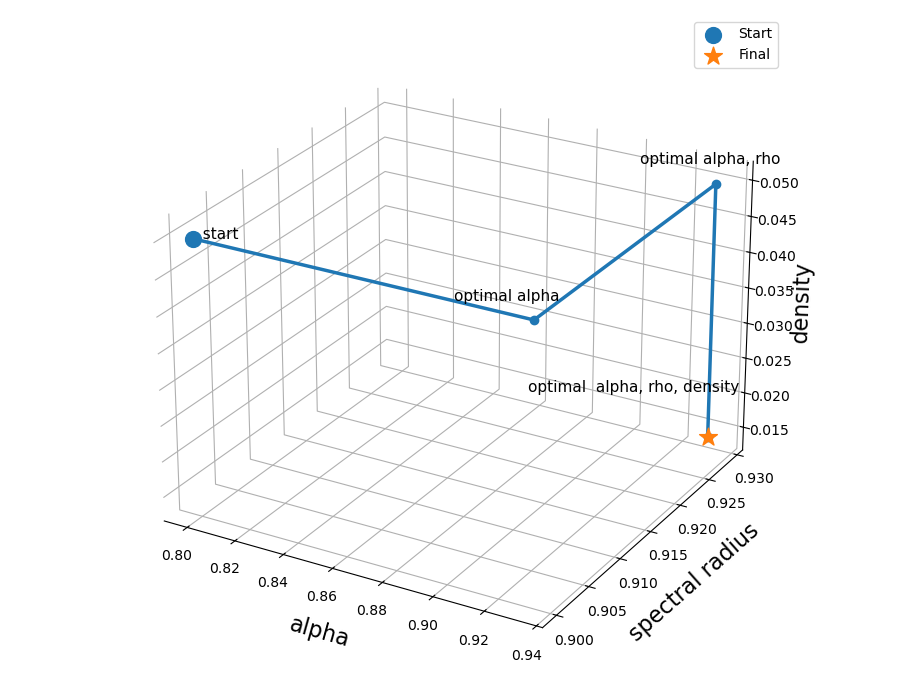

In [3]:
#graph showing the sequential mc optimisation for alpha, sr, density
init = dict(alpha=0.8, spectral_radius=0.9, density=0.05)
opt  = dict(alpha=0.9326634798211147, spectral_radius=0.9288868155097104, density=0.014279791357581456)
h_init  = 13.167
h_final = 18.200

P0 = (init["alpha"], init["spectral_radius"], init["density"])
P1 = (opt["alpha"],  init["spectral_radius"], init["density"])         # after alpha
P2 = (opt["alpha"],  opt["spectral_radius"],  init["density"])         # after rho
P3 = (opt["alpha"],  opt["spectral_radius"],  opt["density"])          # final

path = np.array([P0, P1, P2, P3])
a, r, d = path.T #the path the arrow will follow

#plot
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

#trajectory
ax.plot(a, r, d, marker="o", linewidth=2.5)

#highlight start and final position
ax.scatter(a[0],  r[0],  d[0],  s=130, label=f"Start")
ax.scatter(a[-1], r[-1], d[-1], s=180, marker="*", label=f"Final")

#labels
ax.text(a[0],  r[0],  d[0],  "  start", fontsize=11)
ax.text(a[1]-0.03,  r[1],  d[1],  "optimal alpha", fontsize=11)
ax.text(a[2]-0.03,  r[2],  d[2]+0.0005,  "optimal alpha, rho", fontsize=11)
ax.text(a[3]-0.075,  r[3],  d[3],  "optimal  alpha, rho, density", fontsize=11)

#axes
ax.set_xlabel("alpha", labelpad=10, fontsize=16)
ax.set_ylabel("spectral radius", labelpad=10, fontsize=16)
ax.set_zlabel("density", labelpad=3, fontsize=16)

#view angle
ax.view_init(elev=25, azim=-60)

#making it more visible
for axis in (ax.xaxis, ax.yaxis, ax.zaxis): 
    axis.pane.set_edgecolor("0.85")
    axis.pane.set_alpha(0.0)
ax.grid(True, alpha=0.3)

ax.legend()
plt.tight_layout()
plt.savefig("optimisation_trajectory.pdf", bbox_inches="tight")
plt.show()


##Sequential Monte Carlo search to find optimal values of each hyperparameter

Initial params: {'Nx': 400, 'alpha': 0.8, 'spectral_radius': 0.9, 'density': 0.05}
Initial mean horizon: 12.800 steps


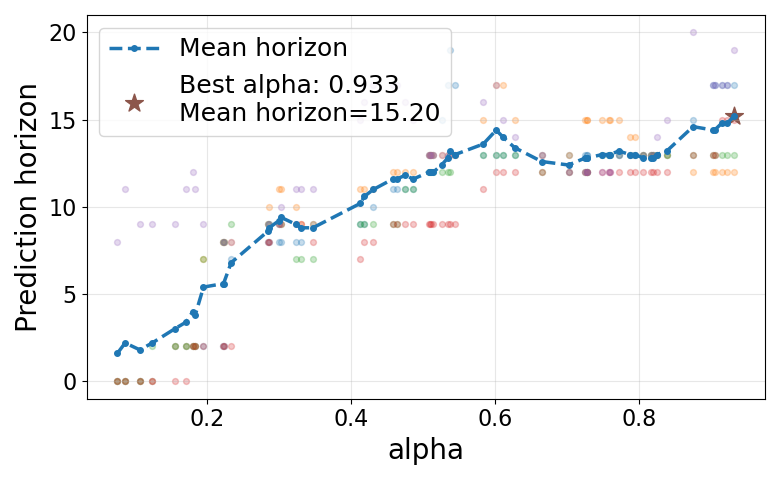

 alpha_opt = 0.9326634798211147


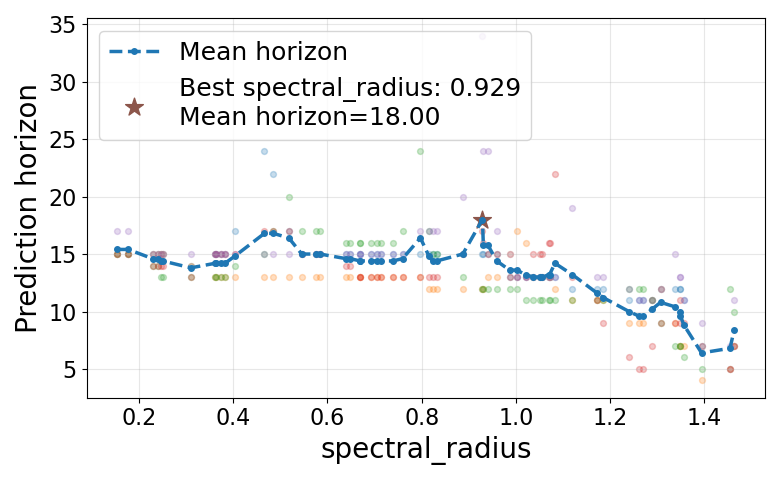

 spectral_radius_opt = 0.9288868155097104


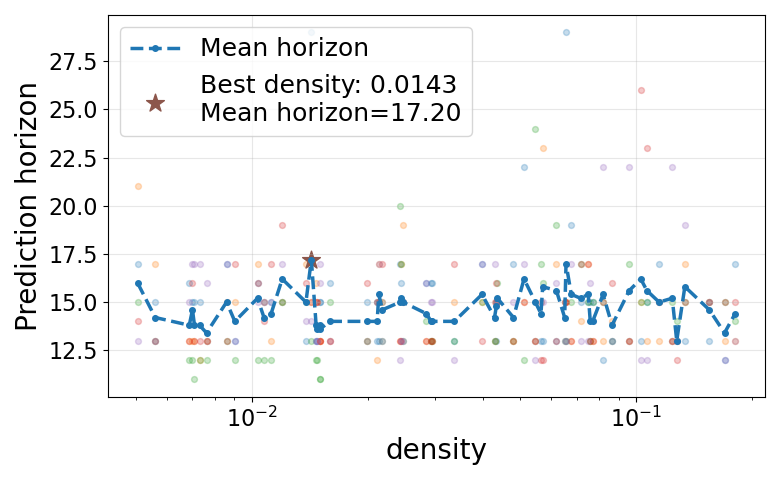

 density_opt = 0.014279791357581456


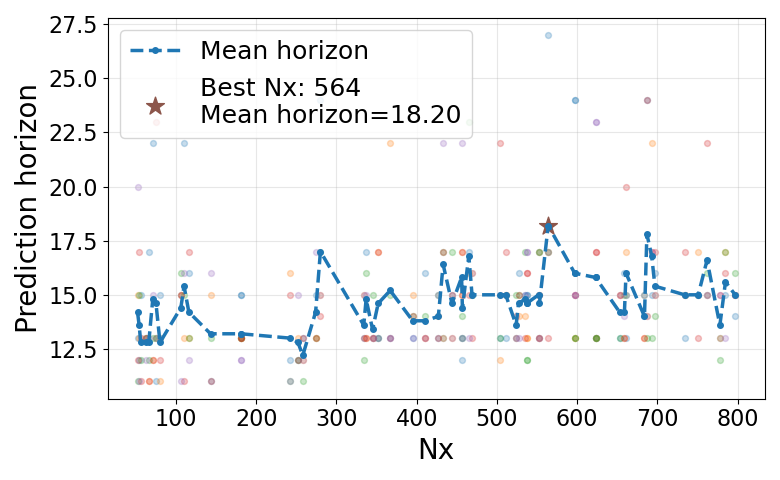

 Nx_opt = 564.0

Final parameters:
              Nx = 564
           alpha = 0.9326634798211147
 spectral_radius = 0.9288868155097104
         density = 0.014279791357581456

Final mean horizon: 18.200 steps


In [4]:
#mc testing of hyperparameters
#tests using prediction horizon
#graphs showing the different horizons occuring from the mc tests for each candidate value for each parameter

# training sequence
r = 3.8
T = 500
s = np.zeros(T + 1); s[0] = 0.5
for n in range(1, T + 1):
    s[n] = r * s[n-1] * (1 - s[n-1])
U = s[:-1][:, None]
Ytarget = s[1:][:, None]

# warmup sequence
T_test = 25
s_test = np.zeros(T_test + 1); s_test[0] = 0.4
for n in range(1, T_test + 1):
    s_test[n] = r * s_test[n-1] * (1 - s_test[n-1])
U_test = s_test[:-1][:, None]


# Horizon scoring with early stopping - was taking too long to run without the early stopping
def horizon_score(rc, U_test, r, s_last_true, K_max=500, error_threshold=0.1): #measures how many steps rc accurately predicts. advances the true system in parallel with the predicted one, stopping both process when error exceeds the threshold
    x0 = np.zeros(rc.Nx)
    X = rc.run_reservoir(U_test, x0=x0)  
    # one-step-ahead predictions on the warmup to get last reservoir state x and last predicted y 
    bias = np.ones((len(U_test), 1))
    Z = np.hstack([bias, U_test, X])
    Yhat = Z @ rc.Wout.T
    x = X[-1]
    y = Yhat[-1]
    s_true = s_last_true
    for k in range(K_max):
        s_true = r * s_true * (1 - s_true) # advance true system
        
        # RC closed-loop step for prediction
        x = rc.step(x, y)
        z = np.hstack([1.0, y, x])
        y = z @ rc.Wout.T

        #checking when error error exceeds threshold
        if abs(y - s_true) > error_threshold:
            return int(k)
    return int(K_max)

# Train and test rc, using horizon_score as test metric
seeds = (0,1,2,3,4)
def score_rc(alpha, spectral_radius, density, Nx, seed, error_threshold=0.1, K_max=500):
    rc = ReservoirComputer(Nx=Nx, Nu=1, Ny=1, alpha=alpha, spectral_radius=spectral_radius, density=density, ridge=1e-6, seed=seed)
    rc.train(U=U, Ytarget=Ytarget)
    return float(horizon_score(rc=rc, U_test=U_test, r=r, s_last_true=s_test[-1], K_max=K_max, error_threshold=error_threshold))

def score_mean(params, seeds=seeds, error_threshold=0.1, K_max=500):
    return float(np.mean([score_rc(seed=sd, error_threshold=error_threshold, K_max=K_max, **params) for sd in seeds]))



# MC - sampling candidate values of a parameter to maximise prediction horizon 
# - also recording horizon of each candidiate so can plot
def mc_scan_param(param_name, sampler_fn, base_params, n_trials=60, rng_seed=0, seeds=seeds, error_threshold=0.1, K_max=500):
    rng = np.random.default_rng(rng_seed)
    #empty arrays for each variable we want to store
    values = np.empty(n_trials, dtype=float)
    mean_scores = np.empty(n_trials, dtype=float)
    per_seed_scores = np.empty((n_trials, len(seeds)), dtype=float)
    best_score = -np.inf
    best_value = None
    for t in range(n_trials):
        params = base_params.copy()
        val = sampler_fn(rng)
        params[param_name] = val
        #score each seed separately so can scatter plot 
        seed_scores = np.array([score_rc(seed=sd, error_threshold=error_threshold, K_max=K_max, **params) for sd in seeds], dtype=float)
        values[t] = float(val)
        per_seed_scores[t, :] = seed_scores
        mean_scores[t] = float(seed_scores.mean())
        if mean_scores[t] > best_score:
            best_score = mean_scores[t]
            best_value = values[t]
    return best_value, best_score, values, mean_scores, per_seed_scores



#Plot horizon - scatter plot for each trial with a mean curve, highlighting the best trial
def plot_mc_horizon_vs_param(param_name, values, mean_scores, per_seed_scores, best_value=None, best_score=None, sort_x=True, logx=False, xlabel=None):
    fig, ax = plt.subplots(figsize=(7.8, 4.8))
    idx = np.argsort(values)
    x = values[idx]
    mean_y = mean_scores[idx]
    runs_y = per_seed_scores[idx] 

    # Scatter all MC runs - one dot per seed per trial
    for j in range(runs_y.shape[1]):
        ax.scatter(x, runs_y[:, j], alpha=0.25, s=18)

    # Dashed mean curve
    ax.plot(x, mean_y, linestyle="--", linewidth=2.5, marker="o", markersize=4, label="Mean horizon")

    # Highlight best
    ax.scatter([best_value], [best_score], s=180, marker="*",
                   label=f"Best {param_name}: {best_value:.3g}\nMean horizon={best_score:.2f}")

    ax.set_xlabel(param_name, fontsize=20)
    ax.set_ylabel("Prediction horizon", fontsize=20)
    ax.tick_params(axis="both", labelsize=16) #fontsize of the numbers on the axis
    ax.grid(True, alpha=0.3) #alpha controls how transparent grid lines are
    if logx:
        ax.set_xscale("log") #density use a log axis as going from 0.005 to 0.2, many orders of magnitude
    ax.legend(loc="upper left", fontsize = 18)
    plt.tight_layout()
    plt.show()



#Run sequential optimisation + plot each scan
error_threshold = 0.1
K_max = 500
params = dict(Nx=400, alpha=0.8, spectral_radius=0.9, density=0.05)
print("Initial params:", params)
initial_mean_horizon = score_mean(params, seeds=seeds,
                                  error_threshold=error_threshold, K_max=K_max)
print(f"Initial mean horizon: {initial_mean_horizon:.3f} steps")
trials = 60

#1 alpha
alpha_opt, alpha_best, alpha_vals, alpha_means, alpha_runs = mc_scan_param("alpha", sampler_fn=lambda rng: float(rng.uniform(0.05, 0.95)),
                                                                           base_params=params, n_trials=trials, rng_seed=1, seeds=seeds, 
                                                                           error_threshold=error_threshold, K_max=K_max)
plot_mc_horizon_vs_param("alpha", alpha_vals, alpha_means, alpha_runs, best_value=alpha_opt, best_score=alpha_best, xlabel=r"$\alpha$")
params["alpha"] = float(alpha_opt)
print(" alpha_opt =", alpha_opt)

#2 spectral radius
sr_opt, sr_best, sr_vals, sr_means, sr_runs = mc_scan_param("spectral_radius", sampler_fn=lambda rng: float(rng.uniform(0.1, 1.5)),
                                                            base_params=params, n_trials=trials, rng_seed=2, seeds=seeds, 
                                                            error_threshold=error_threshold, K_max=K_max)
plot_mc_horizon_vs_param("spectral_radius", sr_vals, sr_means, sr_runs, best_value=sr_opt, best_score=sr_best, xlabel=r"Spectral radius $\rho$")
params["spectral_radius"] = float(sr_opt)
print(" spectral_radius_opt =", sr_opt)

#3 density
density_opt, density_best, dens_vals, dens_means, dens_runs = mc_scan_param("density", sampler_fn=lambda rng: float(10 ** rng.uniform(-2.3, -0.7)),  
                                                                            base_params=params, n_trials=trials, rng_seed=3, seeds=seeds, 
                                                                            error_threshold=error_threshold, K_max=K_max)
plot_mc_horizon_vs_param("density", dens_vals, dens_means, dens_runs, best_value=density_opt, best_score=density_best, logx=True, 
                         xlabel="Density (log scale)")
params["density"] = float(density_opt)
print(" density_opt =", density_opt)

#4 Nx 
Nx_opt, Nx_best, Nx_vals, Nx_means, Nx_runs = mc_scan_param("Nx", sampler_fn=lambda rng: int(rng.integers(50, 800)), base_params=params,
                                                            n_trials=trials, rng_seed=0, seeds=seeds, error_threshold=error_threshold, K_max=K_max)
plot_mc_horizon_vs_param("Nx", Nx_vals, Nx_means, Nx_runs, best_value=Nx_opt, best_score=Nx_best, xlabel=r"Reservoir size $N_x$")
params["Nx"] = int(Nx_opt)
print(" Nx_opt =", Nx_opt)

print("\nFinal parameters:")
for k, v in params.items():
    print(f"{k:>16s} = {v}")

final_mean_horizon = score_mean(params, seeds=seeds, error_threshold=error_threshold, K_max=K_max)
print(f"\nFinal mean horizon: {final_mean_horizon:.3f} steps")
